# ML Zoomcamp 2026 — Homework 1 & Homework 2
**Nicolau Calado Jofilsan** · 2026 cohort (DataTalks.Club)

**EN.** This notebook computes the answers for Homework 1 (Introduction to Machine Learning) and
Homework 2 (Machine Learning for Regression). Both use the pinned 2026 release
`car_fuel_efficiency_2026.csv` from the course repository (`cohorts/2026/data/`), not the car price
dataset from chapter 2 of the book.

**PT.** Este notebook calcula as respostas da Homework 1 (Introdução ao Aprendizado de Máquina) e da
Homework 2 (Regressão). As duas usam a base fixada de 2026, `car_fuel_efficiency_2026.csv`, do
repositório do curso (`cohorts/2026/data/`), e não a base de preços de carros do capítulo 2 do livro.

| Homework | Topic | Deadline (account timezone) |
|---|---|---|
| 1 | NumPy, linear algebra, Pandas | Mon 28/09/2026, 20:00 |
| 2 | Linear regression | Mon 05/10/2026, 20:00 |

Linear regression and RMSE follow the implementation from the module 2 lecture notebook
(`02-carprice.ipynb`) / A regressão linear e o RMSE seguem a implementação da aula do módulo 2.

## 0. Setup and data / Preparação e dados

In [21]:
import os
import urllib.request

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)

DATA_FILE = "car_fuel_efficiency_2026.csv"
DATA_URL = (
    "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/"
    "main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
)

if not os.path.exists(DATA_FILE):
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)

df = pd.read_csv(DATA_FILE)
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


---
# Part A — Homework 1

## Q1. Pandas version / Versão do Pandas

**EN.** The value to report is the one printed by this environment.
**PT.** O valor a informar é o impresso por este ambiente.

In [22]:
print("pandas:", pd.__version__)
print("numpy :", np.__version__)

pandas: 3.0.6
numpy : 2.5.0


## Q2. Records count / Número de registros

In [23]:
n_records = len(df)
print("Q2 =", n_records)

Q2 = 10000


**Answer / Resposta Q2: 10000**

## Q3. Fuel types / Tipos de combustível

In [24]:
print(df["fuel_type"].value_counts())
print("\nQ3 =", df["fuel_type"].nunique())

fuel_type
Gasoline    6913
Diesel      2053
Hybrid      1034
Name: count, dtype: int64

Q3 = 3


**Answer / Resposta Q3: 3** — Gasoline, Diesel, Hybrid

## Q4. Missing values / Valores faltantes

In [25]:
nulls = df.isnull().sum()
print(nulls)
print("\nColumns with missing values:", list(nulls[nulls > 0].index))
print("Q4 =", (nulls > 0).sum())

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

Columns with missing values: ['horsepower', 'acceleration']
Q4 = 2


**Answer / Resposta Q4: 2**

EN: `horsepower` (877 missing) and `acceleration` (264 missing).
PT: `horsepower` (877 faltantes) e `acceleration` (264 faltantes).

## Q5. Max fuel efficiency in Asia / Máxima eficiência na Ásia

In [26]:
max_asia = df[df["origin"] == "Asia"]["fuel_efficiency_mpg"].max()
print("Q5 =", max_asia)

Q5 = 41.2


**Answer / Resposta Q5: 41.2**

## Q6. Median of horsepower before and after imputation

EN: median → mode → `fillna(mode)` → median again.
PT: mediana → moda → `fillna(moda)` → mediana de novo.

In [27]:
median_before = df["horsepower"].median()
mode_hp = df["horsepower"].mode()[0]
median_after = df["horsepower"].fillna(mode_hp).median()

print("median before:", median_before)
print("mode         :", mode_hp)
print("median after :", median_after)

median before: 254.0
mode         : 252.0
median after : 252.0


**Answer / Resposta Q6: Yes, it decreased** — 254.0 → 252.0

EN: the 877 missing values were filled with 252, which is below the original median, so the lower half
of the distribution is pulled down. Mode imputation distorts the distribution of the variable.

PT: os 877 faltantes foram preenchidos com 252, abaixo da mediana original, o que puxa a metade
inferior da distribuição para baixo. Imputar pela moda distorce a distribuição da variável.

## Q7. Sum of weights / Soma dos pesos

EN: normal equation, w = (XᵀX)⁻¹ Xᵀ y, as in the linear algebra lecture.
PT: equação normal, w = (XᵀX)⁻¹ Xᵀ y, como na aula de álgebra linear.

In [28]:
asia = df[df["origin"] == "Asia"]
X = asia[["vehicle_weight", "model_year"]].head(7).values
print("X =\n", X)

XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200])
w = XTX_inv.dot(X.T).dot(y)

print("\nw =", w)
print("Q7 =", w.sum())

X =
 [[4240 1996]
 [4310 1992]
 [4230 1997]
 [4420 1978]
 [3950 2007]
 [4750 2021]
 [4450 2019]]

w = [0.13644777 0.2327492 ]
Q7 = 0.36919696904925486


**Answer / Resposta Q7: 0.369** — 0.36919696904925486

### Homework 1 — answers / respostas

| Question | Answer |
|---|---|
| Q1 Pandas version | as printed above / conforme a saída acima |
| Q2 Records count | **10000** |
| Q3 Fuel types | **3** |
| Q4 Columns with missing values | **2** |
| Q5 Max fuel efficiency (Asia) | **41.2** |
| Q6 Median of horsepower | **Yes, it decreased** |
| Q7 Sum of weights | **0.369** |

---
# Part B — Homework 2 (regression / regressão)

EN: predict `fuel_efficiency_mpg` with linear regression, using five columns only.
PT: prever `fuel_efficiency_mpg` com regressão linear, usando apenas cinco colunas.

In [29]:
base = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
target = "fuel_efficiency_mpg"

df2 = df[base + [target]].copy()
df2.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA: does the target have a long tail? / A variável alvo tem cauda longa?

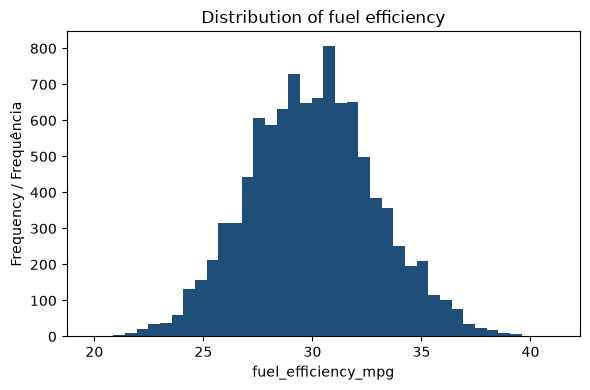

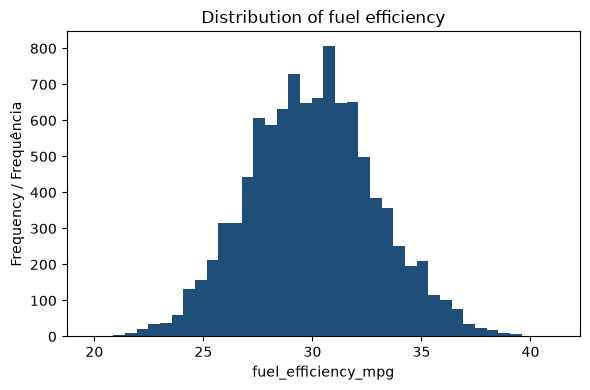

skewness / assimetria: 0.0808


In [30]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df2[target], bins=40, color="#1F4E79")
ax.set_xlabel("fuel_efficiency_mpg")
ax.set_ylabel("Frequency / Frequência")
ax.set_title("Distribution of fuel efficiency")
plt.tight_layout()
plt.show()

print("skewness / assimetria:", round(df2[target].skew(), 4))

**No long tail / Não tem cauda longa.**

EN: the distribution is nearly symmetric (skewness ≈ 0.08), close to a normal. Unlike car prices in the
lecture notebook, there is no need for a `np.log1p` transformation of the target.

PT: a distribuição é quase simétrica (assimetria ≈ 0,08), próxima de uma normal. Diferente do preço dos
carros no notebook da aula, não é preciso aplicar `np.log1p` no alvo.

## Q1. Column with missing values / Coluna com valores faltantes

In [31]:
na2 = df2.isnull().sum()
print(na2)
print("\nQ1 =", list(na2[na2 > 0].index))

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Q1 = ['horsepower']


**Answer / Resposta Q1: `horsepower`** — 877 missing values.

EN: `acceleration` also has missing values in the full dataset, but it is not among the five columns used here.
PT: `acceleration` também tem faltantes na base completa, mas não está entre as cinco colunas usadas aqui.

## Q2. Median of horsepower / Mediana de horsepower

In [32]:
print("Q2 =", df2["horsepower"].median())

Q2 = 254.0


**Answer / Resposta Q2: 254**

## Helper functions: split, training, RMSE / Funções auxiliares

EN: the split follows the homework instructions (60/20/20, shuffled with a seed).
`train_linear_regression_reg` with `r=0` is the unregularized model.

PT: o split segue o enunciado (60/20/20, embaralhado com semente). `train_linear_regression_reg`
com `r=0` é o modelo sem regularização.

In [33]:
def split_data(data, seed):
    n = len(data)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = data.iloc[idx[:n_train]]
    df_val = data.iloc[idx[n_train:n_train + n_val]]
    df_test = data.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test


def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    return np.sqrt(((y_pred - y) ** 2).mean())


def prepare_X(data, fill_value):
    return data[base].fillna(fill_value).values

## Q3. Fill missing values with 0 or with the mean?

EN: the mean is computed on the training set only, to avoid leaking information from validation.
PT: a média é calculada apenas no treino, para não vazar informação da validação.

In [34]:
df_train, df_val, df_test = split_data(df2, seed=42)
y_train = df_train[target].values
y_val = df_val[target].values
y_test = df_test[target].values

mean_hp_train = df_train["horsepower"].mean()
print("training mean of horsepower:", round(mean_hp_train, 4))

scores_fill = {}
for label, fill in [("with 0", 0), ("with mean", mean_hp_train)]:
    w0, w = train_linear_regression_reg(prepare_X(df_train, fill), y_train, r=0.0)
    score = rmse(y_val, w0 + prepare_X(df_val, fill).dot(w))
    scores_fill[label] = round(score, 3)
    print(f"{label:>10}: RMSE = {score:.6f}  ->  rounded: {round(score, 3)}")

print("\nQ3 =", min(scores_fill, key=scores_fill.get))

training mean of horsepower: 254.4634
    with 0: RMSE = 2.205293  ->  rounded: 2.205
 with mean: RMSE = 2.201817  ->  rounded: 2.202

Q3 = with mean


**Answer / Resposta Q3: With mean** — 2.202 vs 2.205

EN: the difference is small but survives rounding to 3 decimals, as the homework requires.
PT: a diferença é pequena, mas sobrevive ao arredondamento em 3 casas, como o enunciado pede.

## Q4. Best regularization parameter / Melhor valor de `r`

In [35]:
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

scores_r = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    scores_r[r] = round(rmse(y_val, w0 + X_val.dot(w)), 4)
    print(f"r = {r:>6}: RMSE = {scores_r[r]}")

print("\nQ4 =", min(scores_r, key=lambda k: (scores_r[k], k)))

r =      0: RMSE = 2.2053
r =   0.01: RMSE = 2.2058
r =    0.1: RMSE = 2.2241
r =      1: RMSE = 2.3492
r =      5: RMSE = 2.4094
r =     10: RMSE = 2.4195
r =    100: RMSE = 2.4292

Q4 = 0


**Answer / Resposta Q4: 0**

EN: RMSE increases monotonically with `r`, so regularization only hurts here. With four features, no
strong collinearity and 6,000 training rows, there is no numerical instability to correct.

PT: o RMSE cresce de forma monótona com `r`, ou seja, a regularização só piora. Com quatro variáveis,
sem colinearidade forte e com 6.000 linhas de treino, não há instabilidade numérica a corrigir.

## Q5. Standard deviation of RMSE across seeds / Desvio-padrão entre sementes

In [36]:
scores_seed = []
for seed in range(10):
    tr, va, _ = split_data(df2, seed)
    w0, w = train_linear_regression_reg(prepare_X(tr, 0), tr[target].values, r=0.0)
    score = rmse(va[target].values, w0 + prepare_X(va, 0).dot(w))
    scores_seed.append(score)
    print(f"seed {seed}: RMSE = {score:.6f}")

std = np.std(scores_seed)
print("\nstd =", std)
print("Q5 =", round(std, 3))

seed 0: RMSE = 2.239204
seed 1: RMSE = 2.202113
seed 2: RMSE = 2.163420
seed 3: RMSE = 2.204359
seed 4: RMSE = 2.201880
seed 5: RMSE = 2.245785
seed 6: RMSE = 2.269721
seed 7: RMSE = 2.190795
seed 8: RMSE = 2.216611
seed 9: RMSE = 2.207037

std = 0.028781274078187116
Q5 = 0.029


**Answer / Resposta Q5: 0.029**

EN: about 1.3% of the average RMSE (~2.2), so the model is stable with respect to the split.
PT: cerca de 1,3% do RMSE médio (~2,2), ou seja, o modelo é estável em relação ao split.

## Q6. Test RMSE, seed 9, train + validation, r=0.001

In [37]:
tr9, va9, te9 = split_data(df2, seed=9)
df_full = pd.concat([tr9, va9])

w0, w = train_linear_regression_reg(prepare_X(df_full, 0), df_full[target].values, r=0.001)
score_test = rmse(te9[target].values, w0 + prepare_X(te9, 0).dot(w))

print("test RMSE =", score_test)
print("Q6 =", round(score_test, 3))

test RMSE = 2.2358277471917636
Q6 = 2.236


**Answer / Resposta Q6: 2.236**

### Homework 2 — answers / respostas

| Question | Answer |
|---|---|
| Q1 Column with missing values | **horsepower** |
| Q2 Median of horsepower | **254** |
| Q3 Filling NAs | **With mean** |
| Q4 Best `r` | **0** |
| Q5 RMSE standard deviation | **0.029** |
| Q6 Test RMSE | **2.236** |

### Notes / Observações

**EN.** 1) Every split calls `np.random.seed` before `np.random.shuffle`, so the results are reproducible.
2) The dataset is the pinned 2026 release downloaded from the course repository.
3) A random row-level split is appropriate here because each row is an independent car. When rows are
grouped by person, session or patient, the split must be done by group (`GroupKFold`), otherwise the
reported metric is inflated.

**PT.** 1) Todo split chama `np.random.seed` antes de `np.random.shuffle`, então os resultados são
reprodutíveis. 2) A base é a versão fixada de 2026, baixada do repositório do curso. 3) O split
aleatório por linha é adequado aqui porque cada linha é um carro independente. Quando as linhas vêm
agrupadas por pessoa, sessão ou paciente, o split precisa ser por grupo (`GroupKFold`), senão a
métrica relatada fica inflada.